In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1460, 81)


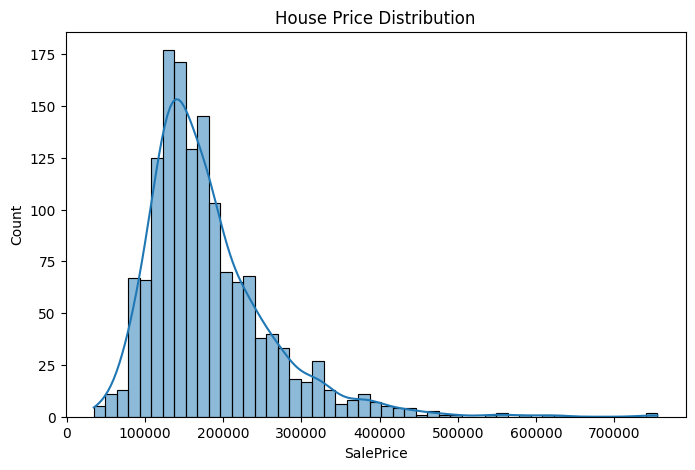

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)

plt.title("House Price Distribution")
plt.show()

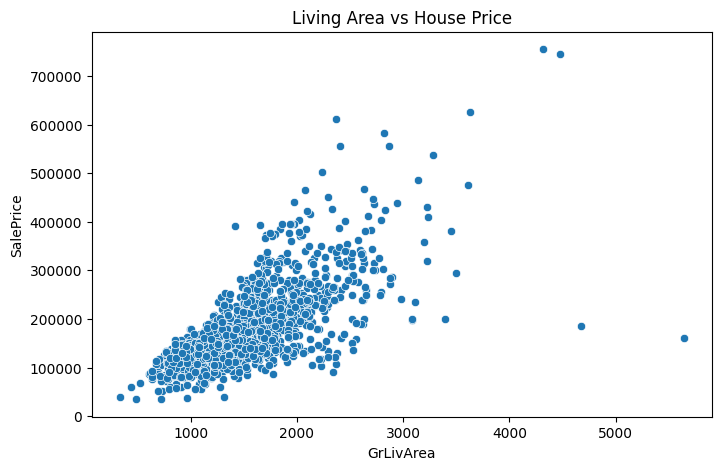

In [5]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["GrLivArea"],
    y=df["SalePrice"]
)

plt.title("Living Area vs House Price")

plt.show()

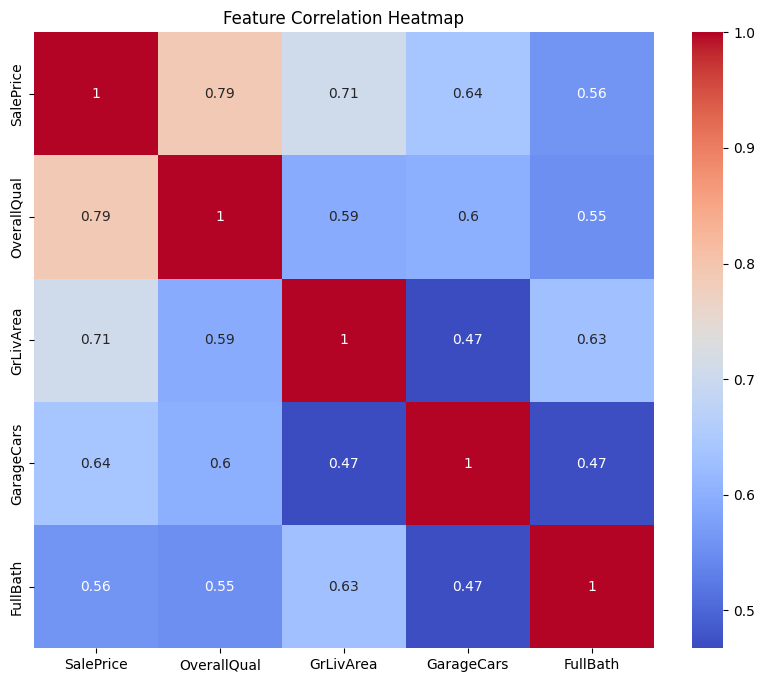

In [6]:
plt.figure(figsize=(10,8))

corr = df[["SalePrice","OverallQual","GrLivArea","GarageCars","FullBath"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [8]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "FullBath"
]

X = df[features]

y = df["SalePrice"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
predictions = model.predict(X_test)

predictions[:5]

array([133023.25      , 311882.92      , 133529.58333333, 177530.        ,
       305336.27      ])

In [12]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("Model Accuracy:", round(score*100,2), "%")

Model Accuracy: 84.32 %


In [19]:
quality = 8
area = 2000
garage = 2
bath = 3

house_price = model.predict(
    [[quality, area, garage, bath]]
)

print("🏠 DREAM HOME PRICE ESTIMATOR")
print("--------------------------------")
print("House Quality:", quality)
print("Living Area:", area, "sq.ft")
print("Garage Capacity:", garage)
print("Bathrooms:", bath)

print("\nEstimated House Price: $", round(house_price[0],2))

if house_price[0] < 150000:
    print("Category: Budget Home")
elif house_price[0] < 300000:
    print("Category: Mid-Range Home")
else:
    print("Category: Luxury Home")

🏠 DREAM HOME PRICE ESTIMATOR
--------------------------------
House Quality: 8
Living Area: 2000 sq.ft
Garage Capacity: 2
Bathrooms: 3

Estimated House Price: $ 282469.0
Category: Mid-Range Home


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [20]:
print("\nHOME BUYER ADVICE")

if house_price[0] < 150000:
    print("Good option for first-time buyers.")
elif house_price[0] < 300000:
    print("Suitable for middle-income families.")
else:
    print("Premium property with luxury features.")


HOME BUYER ADVICE
Suitable for middle-income families.


# Conclusion

The Dream Home Price Estimator uses Machine Learning to predict house prices based on house quality, living area, garage capacity, and bathrooms.

The model achieved good prediction performance and can help users estimate the value of a property before making a purchase decision.